In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales_data=pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
sales_data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [185]:
print("Shape: ", sales_data.shape)
sales_data.isnull().sum()

#This datset contains 9994 rows and 21 columns
#We see that there are no missing vaues in this dataset

Shape:  (9994, 21)


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [186]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [187]:
print("Number of duplicated rows: ",sales_data.duplicated().sum())
#There are no duplicates in this dataset

Number of duplicated rows:  0


In [188]:
#Standaridizing column names
sales_data.columns=sales_data.columns.str.title().str.replace(' ','_')

#Converts datatype of Order_Date and Ship_Date from string to datetime object
sales_data['Order_Date'] = pd.to_datetime(sales_data['Order_Date'])
sales_data['Ship_Date'] = pd.to_datetime(sales_data['Ship_Date'])

sales_data.drop(columns=['Row_Id', 'Order_Id', 'Customer_Id', 'Customer_Name', 'Country', 'Product_Id'], inplace=True)


In [189]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_Date    9994 non-null   datetime64[us]
 1   Ship_Date     9994 non-null   datetime64[us]
 2   Ship_Mode     9994 non-null   str           
 3   Segment       9994 non-null   str           
 4   City          9994 non-null   str           
 5   State         9994 non-null   str           
 6   Postal_Code   9994 non-null   int64         
 7   Region        9994 non-null   str           
 8   Category      9994 non-null   str           
 9   Sub-Category  9994 non-null   str           
 10  Product_Name  9994 non-null   str           
 11  Sales         9994 non-null   float64       
 12  Quantity      9994 non-null   int64         
 13  Discount      9994 non-null   float64       
 14  Profit        9994 non-null   float64       
dtypes: datetime64[us](2), float64(3), int64(2), str(8

##Data Loading and Cleaning

**1. Checking missing values**
- Checked for missing data by 'sales_data.isnull().sum()'
- Found no missing values

**2. Checked for duplicate rows**
- Checked for duplicate rows by 'sales_data.duplicated().sum()'
- Found no duplicate records

**3. Date Columns**
- `Order Date` and `Ship Date` were loaded as object (string) type
- Converted both to `datetime` format using `pd.to_datetime()`
- This is essential for time series analysis in later tasks

**4. Column Names**
- Standardized all column names to lowercase with underscores
- Example: `Order Date` → 'Order_Date'


In [190]:
sales_data.describe()

,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [191]:
print(f"Mean Sales: ${sales_data['Sales'].mean():.2f}")
print(f"Median Sales: ${sales_data['Sales'].median():.2f}")

print(f"Mode of Category: {sales_data['Category'].mode()[0]}")
print(f"Mode of Sub-Category: {sales_data['Sub-Category'].mode()[0]}")

print(f"Std Dev of Profit: ${sales_data['Profit'].std():.2f}")
print(f"Mean Discount: {sales_data['Discount'].mean():.2f}")
print(f"Mean Profit: ${sales_data['Profit'].mean():.2f}")

Mean Sales: $229.86
Median Sales: $54.49
Mode of Category: Office Supplies
Mode of Sub-Category: Binders
Std Dev of Profit: $234.26
Mean Discount: 0.16
Mean Profit: $28.66


## Descriptive Statistics

**Is mean sales much higher than median? What does that tell you?**
- The mean sales are much higher than median sales by $175.37. This indicates that large orders are contributing to the sales.

**Are there negative profit values? What does that mean?**
- There are negative profits indicating that there has been a loss in some sales 

**What is the average discount being given?**
- The average discount been given is $0.16

**Which category and sub-category appears most frequently?**
- Most of the sales comes form the Office Supplies category and Binders sub-category


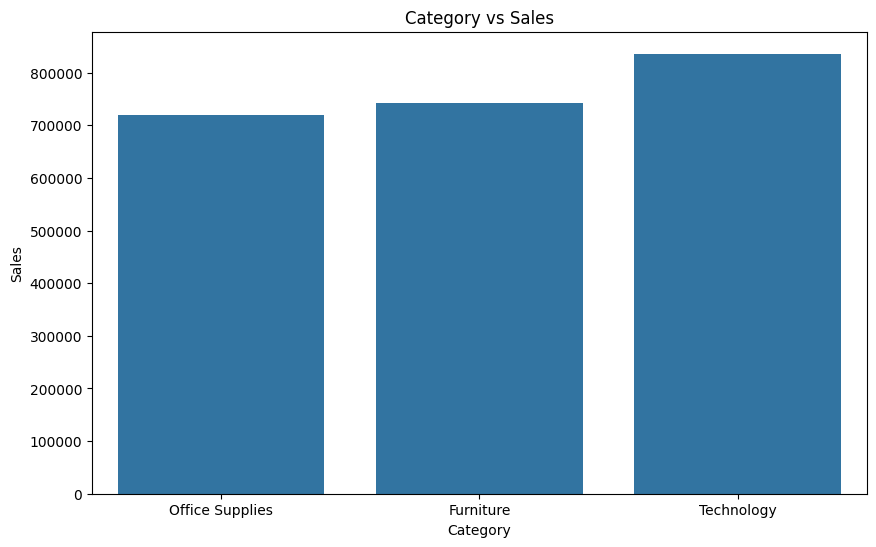

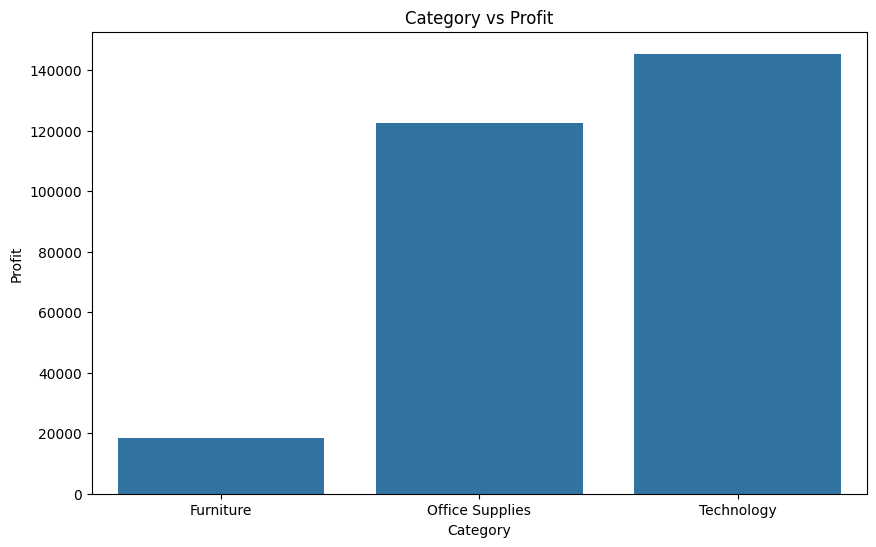

In [192]:
#Category wise sales
category_sales=sales_data.groupby('Category')['Sales'].sum().sort_values()
category_profit=sales_data.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(y=category_sales.values, x=category_sales.index)
plt.title("Category vs Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig('category_sales_analysis.png')

plt.figure(figsize=(10,6))

sns.barplot(y=category_profit.values, x=category_profit.index)
plt.title("Category vs Profit")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.savefig('category_profit_analysis.png')

**Which category sells the most? Does it also make the most profit?**
- Technology has the highest sales and it also makes the highest profit

**Is there a category that sells well but has low profit? Why might that be?**
- Furiture has good sales but low profit.
- Possible aReasons:
    - Transportation problem as it is bulky
    - Has low profit compared to Technology 
    - Some furniture have low profits such as tables

**What should the business focus on based on this?**
- Identify the products causing the low profits in furniture
- Try repricing or replacing the items or its price otherwise use a different discount strategy to improve business

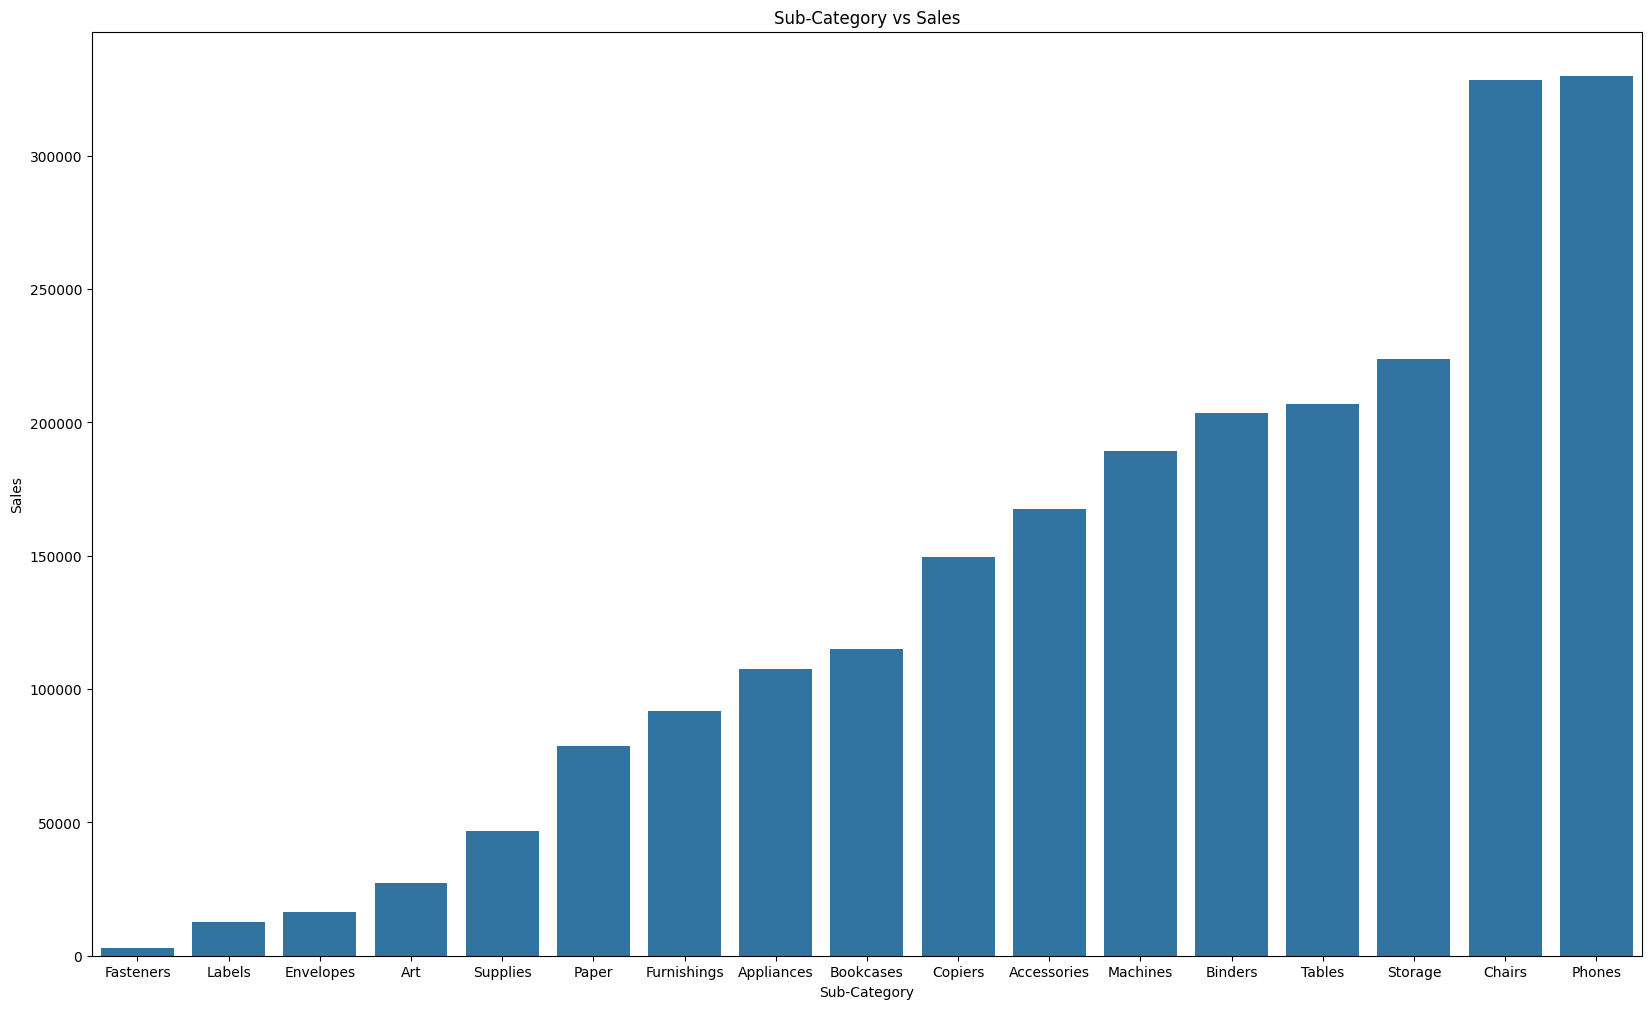

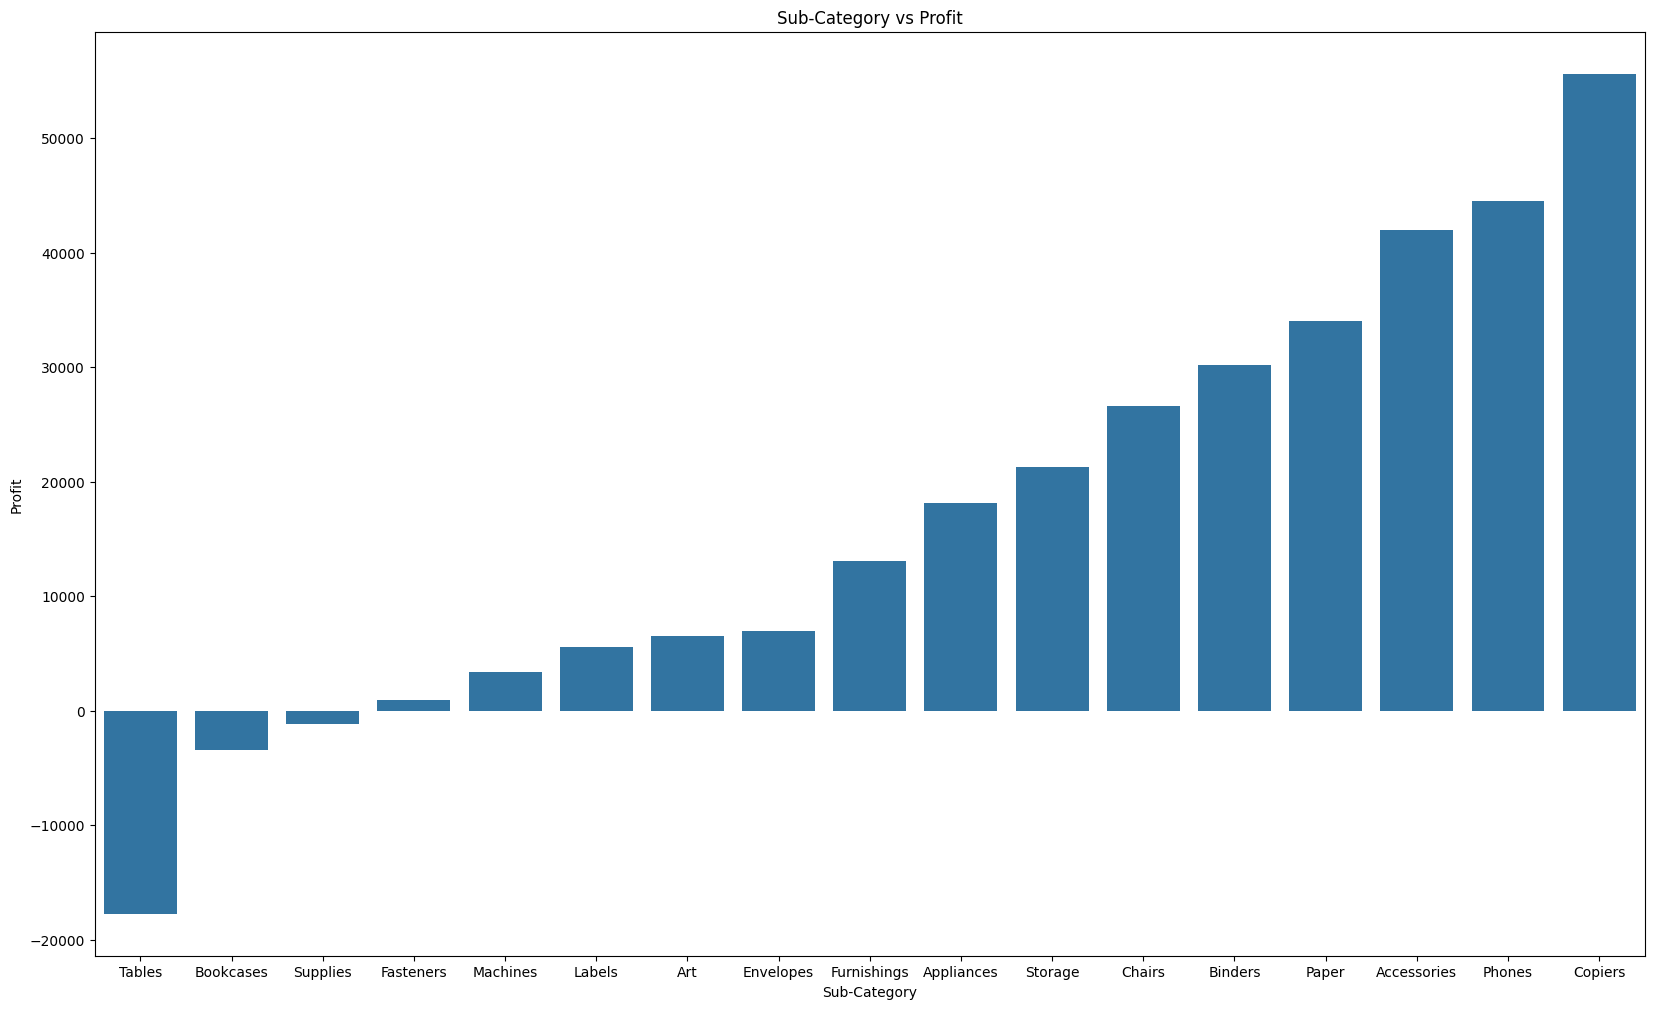

In [193]:
sub_sales = sales_data.groupby('Sub-Category')['Sales'].sum().sort_values()
sub_profit = sales_data.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(20,12))

sns.barplot(y=sub_sales.values, x=sub_sales.index)
plt.title("Sub-Category vs Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.savefig('sub-category_sales_analysis.png')

plt.figure(figsize=(20,12))

sns.barplot(y=sub_profit.values, x=sub_profit.index)
plt.title("Sub-Category vs Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.savefig('sub-category_profit_analysis.png')

**Which sub-categories are loss-making?**
- Tables, Bookcases, Art

**Which sub-category has the highest profit despite not being the top seller?**
- Copiers

**What business decision would you make based on these two charts together?**
- Some strategy must be taken for increaisng the profits of Tables, Bookcases and Art
   - Maybe rewise the discount methods
- Supplies and Machines seems to brign less profits despite the big sales
    - It should be repriced or replaced with a new idea
- Methods should be applied for balancing the sales and revenue for Chairs and Phones, as profits as not so high considering the huge sales of these two products.

Region
West       21.948662
East       16.722696
South      16.351903
Central   -10.407294
Name: Profit_Margin, dtype: float64


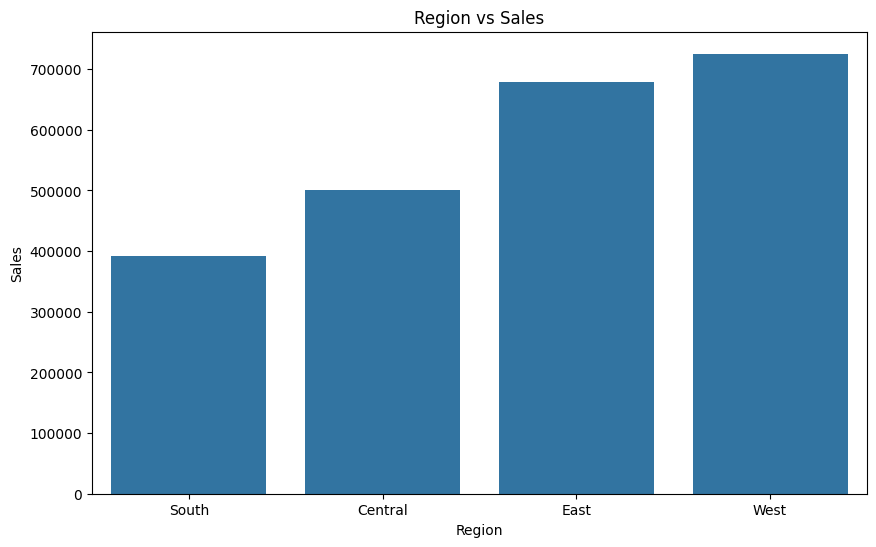

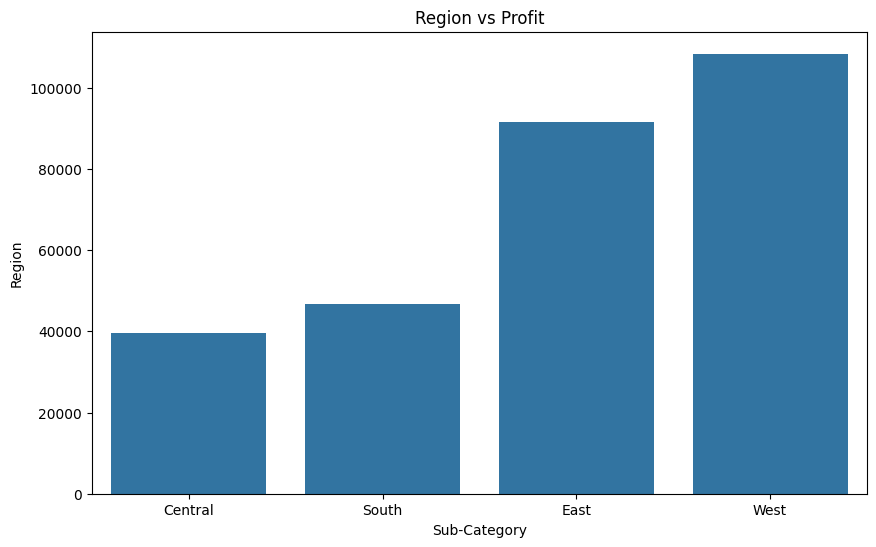

In [194]:
reg_sales = sales_data.groupby('Region')['Sales'].sum().sort_values()
reg_profit = sales_data.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(y=reg_sales.values, x=reg_sales.index)
plt.title("Region vs Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.savefig('region_sales_analysis.png')

plt.figure(figsize=(10,6))

sns.barplot(y=reg_profit.values, x=reg_profit.index)
plt.title("Region vs Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Region")

plt.savefig('region_profit_analysis.png')

sales_data['Profit_Margin'] = sales_data['Profit'] / sales_data['Sales'] * 100
print(sales_data.groupby('Region')['Profit_Margin'].mean().sort_values(ascending=False))

**Which region leads in both sales and profit?**
- The west Region leads in both sales profits

**Which region has the best profit margin vs just raw sales?**
- West region has the best profit and raw sales

**Are any regions selling a lot but making little profit?**
- Central region has more sales but less profit(negative profit)

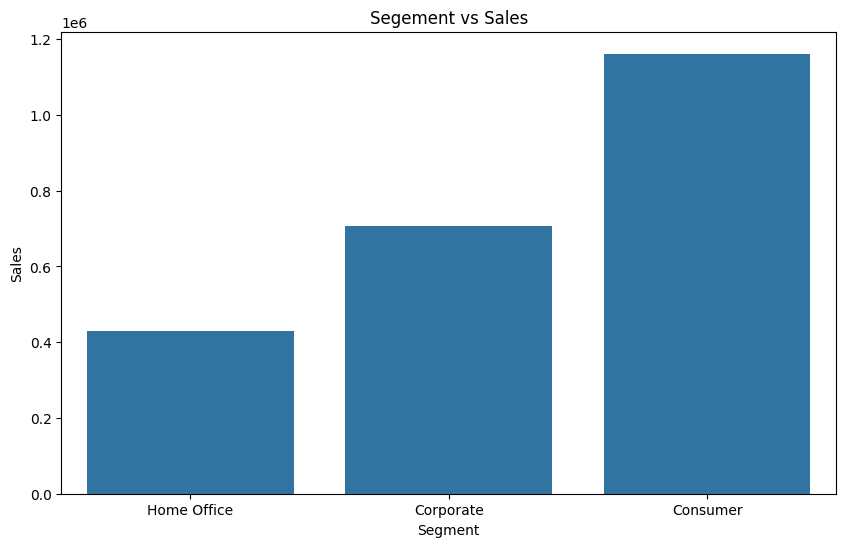

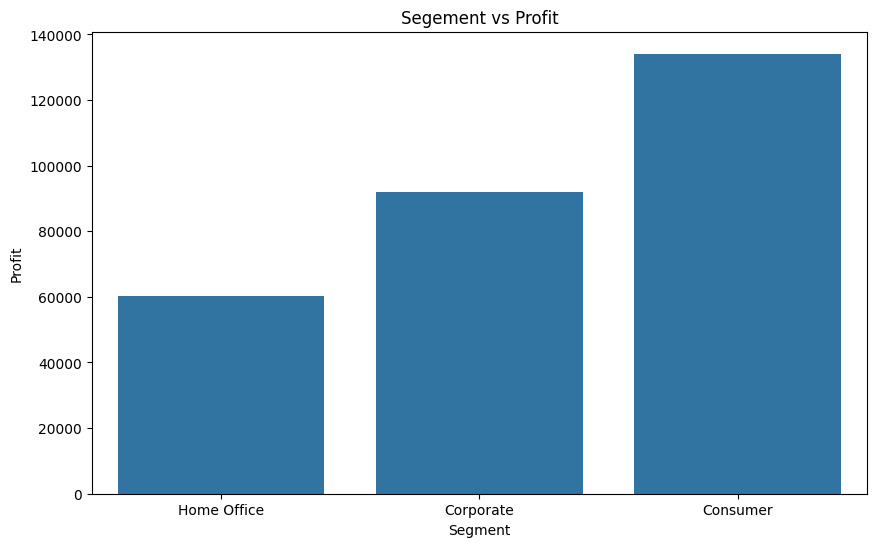

In [195]:
segment_sales = sales_data.groupby('Segment')['Sales'].sum().sort_values()
segment_profit = sales_data.groupby('Segment')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(y=segment_sales.values, x=segment_sales.index)
plt.title("Segement vs Sales")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.savefig("segment_sales_analysis.png")

plt.figure(figsize=(10,6))

sns.barplot(y=segment_profit.values, x=segment_profit.index)
plt.title("Segement vs Profit")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.savefig("segment_profit_analysis.png")


**Which customer segment generates the most revenue?**
- Consumer segmetn generated the most revenue

**Which segment places the most orders but perhaps spends less per order?**
- Corporate segment spends less per order and orders more

**Which segment should the business prioritize for growth?**
- Home Office should be prioritized for growth

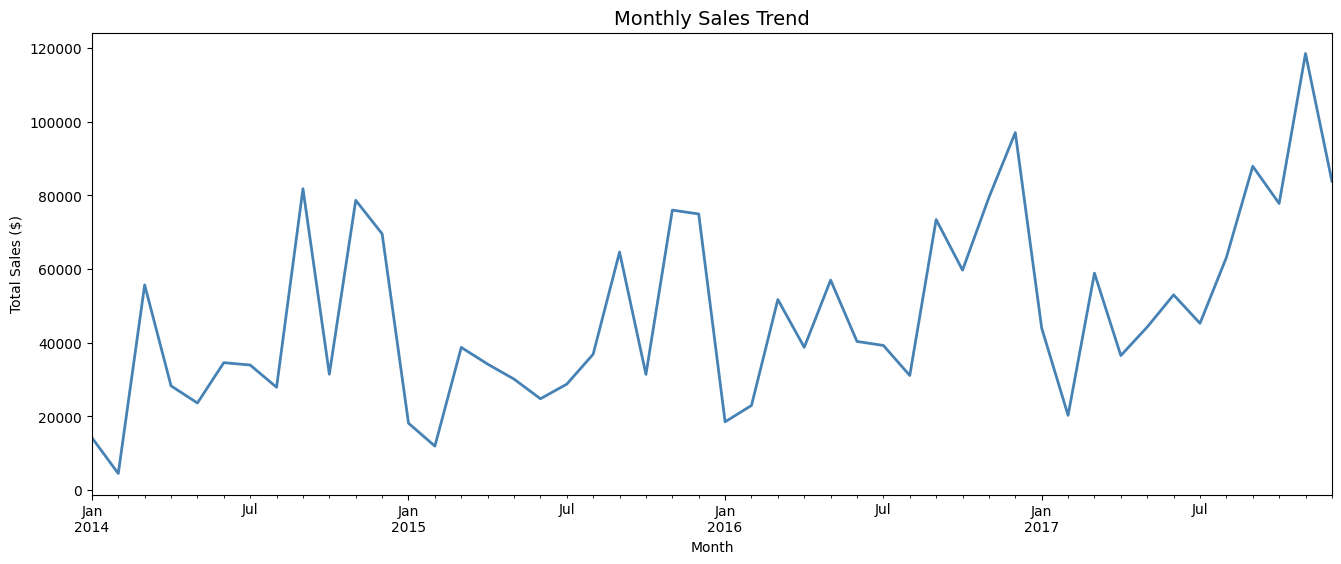

In [196]:
sales_data['Year_Month'] = sales_data['Order_Date'].dt.to_period('M')
monthly_sales = sales_data.groupby('Year_Month')['Sales'].sum()

plt.figure(figsize=(16, 6))

monthly_sales.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')

plt.savefig('monthly_sales_trend.png')

<Figure size 1400x600 with 0 Axes>

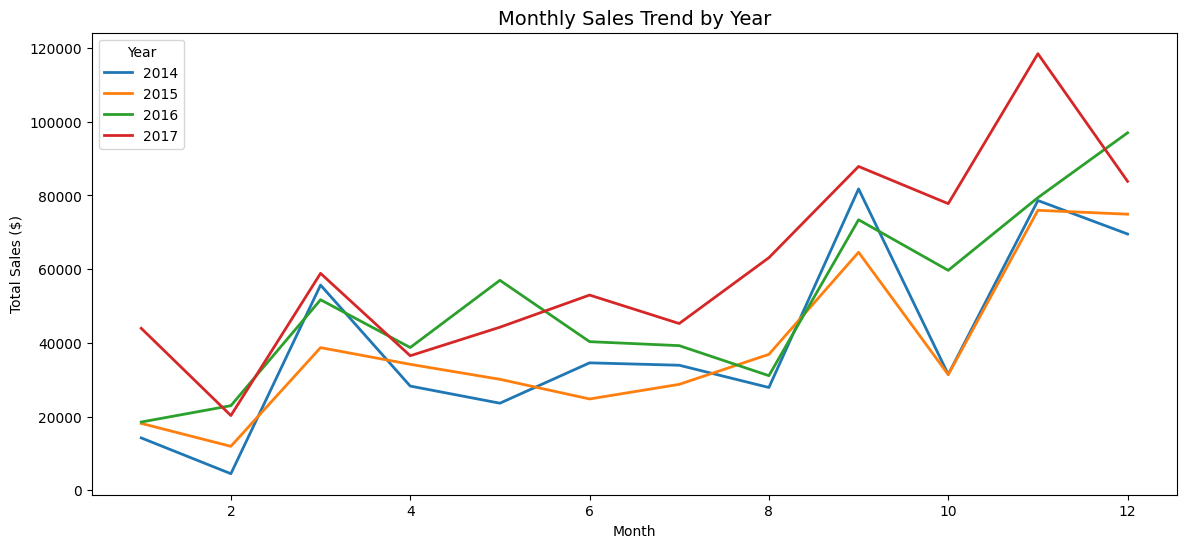

In [197]:
sales_data['Year'] = sales_data['Order_Date'].dt.year
sales_data['Month'] = sales_data['Order_Date'].dt.month

yearly_monthly = sales_data.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)

plt.figure(figsize=(14, 6))

yearly_monthly.plot(figsize=(14, 6), linewidth=2)

plt.title('Monthly Sales Trend by Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.legend(title='Year')

plt.savefig('yearly_monthly_trend.png')

## TIME SERIES ANALYSIS ##

**Is there an overall upward trend in sales year over year?**
- Yes there is an upward trend in the sales in an year

**Which months consistently see the highest sales? (seasonal pattern?)**
- November and December see the highest seasonal pattern
**Are there any sudden spikes or drops? What might explain them?**
- Yes there are sudden drops possible reasons might be off-season sales, less marketing activity, reduced customer demand
- As for sudden spikes it could be due to seasonal sales, customer demand, bulk sales
**What does this tell a business about when to push marketing campaigns?**
- The business should increase marketing efforts, inventory levels, and promotional campaigns before and during peak sales months such as November and December. Launching campaigns shortly before these periods can maximize revenue by capitalizing on increased customer demand.
During lower-performing months, targeted promotions and discounts may help maintain steady sales and reduce seasonal slowdowns.

    Discount      Profit
0       0.00   66.900292
1       0.10   96.055074
2       0.15   27.288298
3       0.20   24.702572
4       0.30  -45.679636
5       0.32  -88.560656
6       0.40 -111.927429
7       0.45 -226.646464
8       0.50 -310.703456
9       0.60  -43.077212
10      0.70  -95.874060
11      0.80 -101.796797


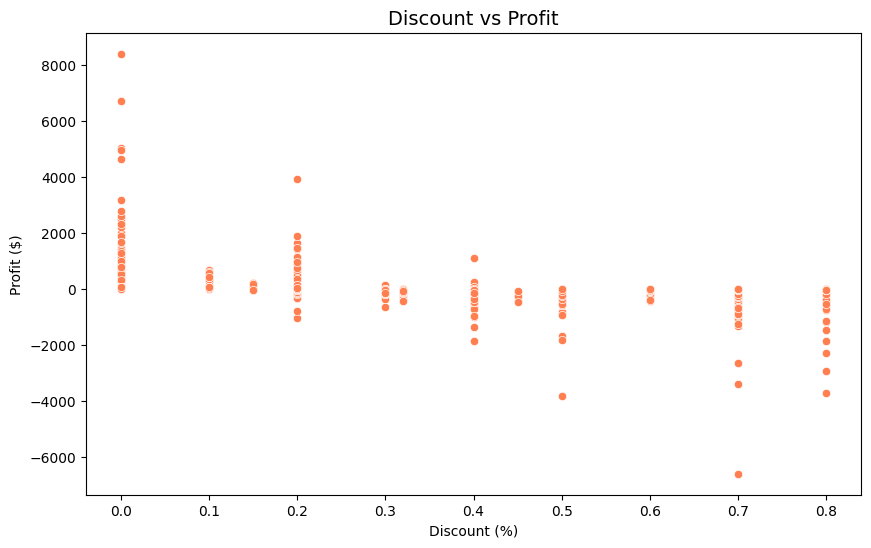

In [198]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=sales_data, x='Discount', y='Profit', color='coral')
plt.title('Discount vs Profit', fontsize=14)
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')

plt.savefig('discount_vs_profit.png')


# Average profit at each discount level
discount_profit = sales_data.groupby('Discount')['Profit'].mean().reset_index()
print(discount_profit)

**Is there a clear negative relationship between discount and profit?**
- The scatter plot shows a clear negative relationship between discount and profit. Higher discounts are associated with lower profits.
**At what discount level does profit start going negative?**
- Profit starts turning negative for some orders at around 20% discount.
**What recommendation would you give the business about their discounting strategy?**
- Keep discounts low whenever possible.
- Carefully review promotions above 40% discount.

Ship_Mode    First Class  Same Day  Second Class  Standard Class
Segment                                                         
Consumer             769       317          1020            3085
Corporate            485       114           609            1812
Home Office          284       112           316            1071


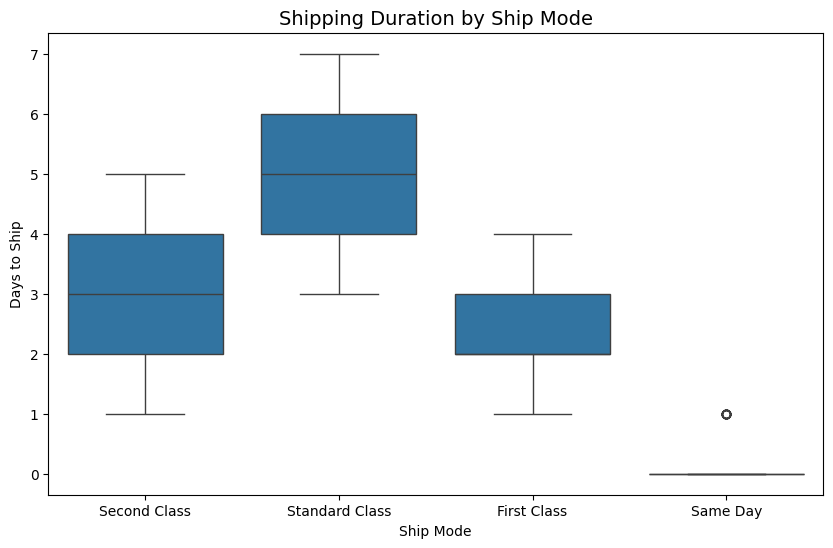

In [199]:
# Calculate shipping duration
sales_data['Shipping_Days'] = (sales_data['Ship_Date'] - sales_data['Order_Date']).dt.days

plt.figure(figsize=(10, 6))

sns.boxplot(data=sales_data, x='Ship_Mode', y='Shipping_Days')

plt.title('Shipping Duration by Ship Mode', fontsize=14)
plt.xlabel('Ship Mode')
plt.ylabel('Days to Ship')

plt.savefig('shipping_analysis.png')


# Which ship mode is most used per segment
print(pd.crosstab(sales_data['Segment'], sales_data['Ship_Mode']))

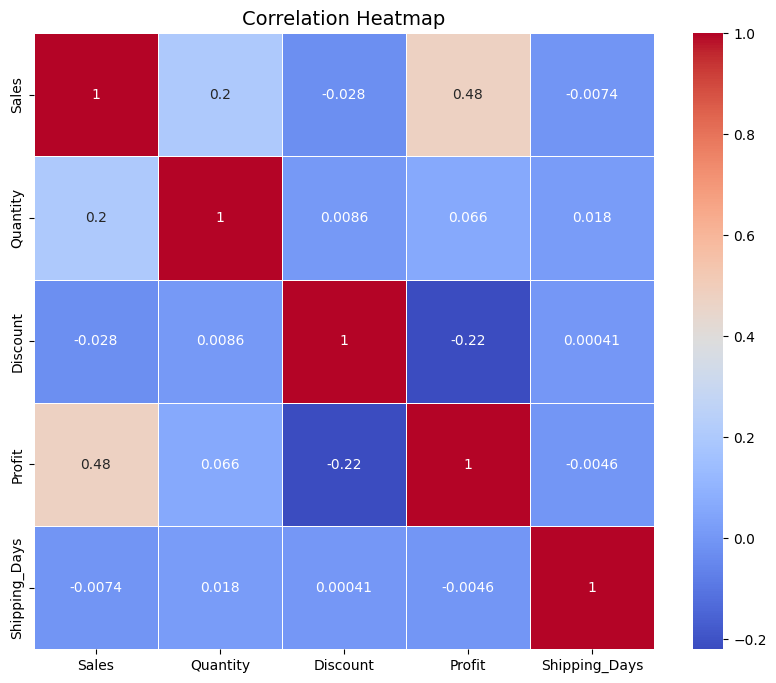

In [200]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Days']

corr = sales_data[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)

plt.savefig('correlation_heatmap.png')


## RECOMMENDATIONS ##
- The Technology category generates the highest profit margin — the business should increase marketing spend here.
- Tables sub-category is consistently loss-making — consider revising pricing.
- Discounts above 20% consistently result in negative profit — cap discounts at 20% across all categories.
- The West region leads in both sales and profit — use it as a model for replicating strategies in the South.
- Sales peak in November and December — plan inventory and marketing campaigns ahead of Q4.
- Consumer segment places the most orders — loyalty programs targeting this segment could significantly boost revenue.

In [ ]:
sales_data.to_csv('superstore_eda.csv', index=False)